# Ejemplo aplicado: regresión lineal — Diabetes (progresión)

Misma plantilla que [01-regresion-lineal.ipynb](../01-regresion-lineal.ipynb), ya configurada para `diabetes.csv` (target `disease_progression`, separador `,`). Target: progresión de la enfermedad (continuo). Incluye faltantes en algunas columnas (el imputer del pipeline los gestiona).

> Para un CSV nuevo, parte de la **plantilla genérica** `01-regresion-lineal.ipynb`, no de este archivo.


In [1]:
# =============================================================================
# Helpers — funciones reutilizables (misma lógica en todo el benchmark)
# =============================================================================
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer  # pipeline distinto por tipo de columna
from sklearn.impute import SimpleImputer  # rellenar NaN antes de escalar/codificar
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline  # encadena: preprocesado → modelo
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
def infer_feature_columns(df, target_col, drop_cols, feature_cols):
    """Lista de columnas predictoras (X)."""
    if feature_cols is not None:
        return list(feature_cols)
    exclude = {target_col, *drop_cols}
    return [c for c in df.columns if c not in exclude]


def infer_column_types(X, numeric_cols=None, categorical_cols=None):
    """Separa columnas numéricas y categóricas para el ColumnTransformer."""
    if numeric_cols is None:
        numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    if categorical_cols is None:
        categorical_cols = X.select_dtypes(
            include=["object", "category", "bool", "string"]
        ).columns.tolist()
    return list(numeric_cols), list(categorical_cols)


def build_preprocess(numeric_cols, categorical_cols):
    """Preprocesador compartido por todos los modelos (fit solo en train dentro del Pipeline)."""
    transformers = []
    if numeric_cols:
        transformers.append(
            (
                "num",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_cols,
            )
        )
    if categorical_cols:
        transformers.append(
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "encoder",
                            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                        ),
                    ]
                ),
                categorical_cols,
            )
        )
    if not transformers:
        raise ValueError("No hay columnas numéricas ni categóricas para preprocesar.")
    return ColumnTransformer(transformers, remainder="drop")


def split_train_val_test(X, y, test_size, val_size, random_state, stratify=False):
    """Divide en train, validación y test (dos llamadas a train_test_split).

    - test_size: fracción del total para test (hold-out final, paso 9).
    - val_size: fracción de train+val; el benchmark (paso 8) usa solo val.
    Con test_size=0.2 y val_size=0.25 → ~60 % train, ~20 % val, ~20 % test.
    """
    kw = dict(test_size=test_size, random_state=random_state)
    if stratify:
        kw["stratify"] = y
    X_tv, X_test, y_tv, y_test = train_test_split(X, y, **kw)
    kw2 = dict(test_size=val_size, random_state=random_state)
    if stratify:
        kw2["stratify"] = y_tv
    X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, **kw2)
    return X_train, X_val, X_test, y_train, y_val, y_test


def discretize_series(series, n_bins=5, max_classes=25):
    """Discretiza una serie para tablas target×feature (redondeo o bins por cuantiles)."""
    s = pd.Series(series)
    if s.nunique() <= max_classes:
        return np.round(s).astype(int).to_numpy(), "valores redondeados"
    edges = np.unique(np.quantile(s.dropna(), np.linspace(0, 1, n_bins + 1)))
    if len(edges) < 2:
        edges = np.linspace(float(s.min()), float(s.max()), n_bins + 1)
    binned = np.digitize(s, edges[1:-1])
    return binned, f"{len(edges) - 1} intervalos (cuantiles)"



## 1. Explorar el CSV (antes de CONFIG)

Ejecuta esta celda con un CSV nuevo **solo** para ver columnas, tipos y faltantes. Con eso rellenas `TARGET_COL`, `DROP_COLS`, etc. en la celda siguiente.

Si el `head()` se ve mal (todo en una columna), cambia `PREVIEW_SEP` a `","`, `";"` o `"\t"`.

In [2]:
# Ruta y separador del CSV (único ajuste antes de ver la tabla)
PREVIEW_PATH = "../data/diabetes.csv"
PREVIEW_SEP = ","  # Prueba: ","  |  ";"  |  "\t"

df_preview = pd.read_csv(PREVIEW_PATH, sep=PREVIEW_SEP)

print(f"Filas: {len(df_preview):,}  |  Columnas: {len(df_preview.columns)}")
print("\n--- Nombres de columnas (índice : nombre) ---")
for i, col in enumerate(df_preview.columns):
    print(f"  {i:2d}: {col!r}")

print("\n--- Tipos de datos (dtypes) ---")
print(df_preview.dtypes)

print("\n--- Primeras filas ---")
display(df_preview.head())

print("\n--- Valores faltantes por columna ---")
missing = df_preview.isna().sum()
if missing.any():
    display(missing[missing > 0].to_frame("nulos"))
else:
    print("No hay valores faltantes.")

# Sugerencia para NUMERIC_COLS / CATEGORICAL_COLS en CONFIG (si dejas None, se infieren igual)
_num = df_preview.select_dtypes(include=[np.number]).columns.tolist()
_cat = df_preview.select_dtypes(include=["object", "category", "bool", "string"]).columns.tolist()
print("\n--- Sugerencia automática de tipos ---")
print("Numéricas (int/float):", _num)
print("Categóricas (object/category/bool/string):", _cat)

print(
    "\n>>> Siguiente paso: en CONFIG usa el mismo PREVIEW_PATH → DATA_PATH, "
    "PREVIEW_SEP → CSV_SEP, y elige TARGET_COL (columna numérica a predecir)."
)

Filas: 442  |  Columnas: 11

--- Nombres de columnas (índice : nombre) ---
   0: 'age'
   1: 'sex'
   2: 'bmi'
   3: 'blood_pressure'
   4: 'total_cholesterol'
   5: 'ldl'
   6: 'hdl'
   7: 'thyroid'
   8: 'log_triglycerides'
   9: 'blood_sugar_level'
  10: 'disease_progression'

--- Tipos de datos (dtypes) ---
age                    float64
sex                    float64
bmi                    float64
blood_pressure         float64
total_cholesterol      float64
ldl                    float64
hdl                    float64
thyroid                float64
log_triglycerides      float64
blood_sugar_level      float64
disease_progression    float64
dtype: object

--- Primeras filas ---


,age,sex,bmi,blood_pressure,total_cholesterol,ldl,hdl,thyroid,log_triglycerides,blood_sugar_level,disease_progression
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0



--- Valores faltantes por columna ---


,nulos
bmi,22



--- Sugerencia automática de tipos ---
Numéricas (int/float): ['age', 'sex', 'bmi', 'blood_pressure', 'total_cholesterol', 'ldl', 'hdl', 'thyroid', 'log_triglycerides', 'blood_sugar_level', 'disease_progression']
Categóricas (object/category/bool/string): []

>>> Siguiente paso: en CONFIG usa el mismo PREVIEW_PATH → DATA_PATH, PREVIEW_SEP → CSV_SEP, y elige TARGET_COL (columna numérica a predecir).


## 2. CONFIG

In [3]:
# ========== CONFIG (editar al cambiar de dataset) ==========
# Mismos valores que PREVIEW_PATH y PREVIEW_SEP en la celda de exploración
DATA_PATH = "../data/diabetes.csv"
# Ejemplo otro archivo: DATA_PATH = "../data/wine_quality_red.csv"

CSV_SEP = ","
# Ejemplos: "," (estándar)  |  ";" (wine quality)  |  "\t" (TSV)

# Columna que quieres PREDECIR (consumo en millas por galón)
TARGET_COL = "disease_progression"
# Progresión de la diabetes (variable continua a predecir)

# Columnas que NO deben usarse como features (ids, texto libre, duplicados del target)
DROP_COLS = []
# sex (1/2) es numérico en el CSV; para tratarlo como categórica: CATEGORICAL_COLS = ["sex"]
# Ejemplos: ["id", "id_vivienda"]  |  ["PassengerId", "Name"] (Titanic, si el target es Survived)

# Si None: todas las columnas salvo TARGET_COL y DROP_COLS
FEATURE_COLS = None
# Ejemplo manual: FEATURE_COLS = ["alcohol", "volatile acidity", "sulphates"]

# Si None: se infieren por tipo (int/float vs object/category)
NUMERIC_COLS = None
# Ejemplo: NUMERIC_COLS = ["edad", "ingresos", "hijos"]

CATEGORICAL_COLS = None
# Ejemplo: CATEGORICAL_COLS = ["ciudad", "tipo_contrato", "color"]

# Fracción para test (0.2 = 20 % test, 80 % train)
TEST_SIZE = 0.2  # fracción total para test (hold-out final)
VAL_SIZE = 0.25  # fracción de train+val → validación (~20 % del total si TEST_SIZE=0.2)
RANDOM_STATE = 42

# Métrica para ordenar la tabla de comparación (mayor R² = mejor en regresión)
METRIC_PRINCIPAL = "r2"


def build_models():
    """Diccionario nombre → estimador. Comenta líneas para excluir modelos del benchmark."""
    from sklearn.ensemble import (
        GradientBoostingRegressor,
        HistGradientBoostingRegressor,
        RandomForestRegressor,
    )
    from sklearn.linear_model import Lasso, LinearRegression, Ridge
    from xgboost import XGBRegressor
    from catboost import CatBoostRegressor

    models = {
        "LinearRegression": LinearRegression(),
        "Ridge": Ridge(random_state=RANDOM_STATE),
        "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=5000),
        "RandomForest": RandomForestRegressor(
            n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
        ),
        "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "HistGradientBoosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        "XGBoost": XGBRegressor(
            random_state=RANDOM_STATE, verbosity=0, n_estimators=100, n_jobs=-1
        ),
        "CatBoost": CatBoostRegressor(
            random_state=RANDOM_STATE,
            verbose=False,
            iterations=100,
            allow_writing_files=False,
        ),
    }
    return models


MODELS = build_models()



## 3. Carga de datos

In [4]:
df = pd.read_csv(DATA_PATH, sep=CSV_SEP)
print("Shape:", df.shape)
df.head()

Shape: (442, 11)


,age,sex,bmi,blood_pressure,total_cholesterol,ldl,hdl,thyroid,log_triglycerides,blood_sugar_level,disease_progression
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


## 4. Calidad de datos

In [5]:
print(df.info())
print("\nFaltantes por columna:")
missing = df.isna().sum()
print(missing[missing > 0] if missing.any() else "Sin valores faltantes")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  442 non-null    float64
 1   sex                  442 non-null    float64
 2   bmi                  420 non-null    float64
 3   blood_pressure       442 non-null    float64
 4   total_cholesterol    442 non-null    float64
 5   ldl                  442 non-null    float64
 6   hdl                  442 non-null    float64
 7   thyroid              442 non-null    float64
 8   log_triglycerides    442 non-null    float64
 9   blood_sugar_level    442 non-null    float64
 10  disease_progression  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None

Faltantes por columna:
bmi    22
dtype: int64


## 5. Análisis de features y dependencias

Explora la relación del **target** con las columnas predictoras (correlación y matriz target×feature con valores discretizados). Así ves dependencias en los datos **antes** de entrenar.



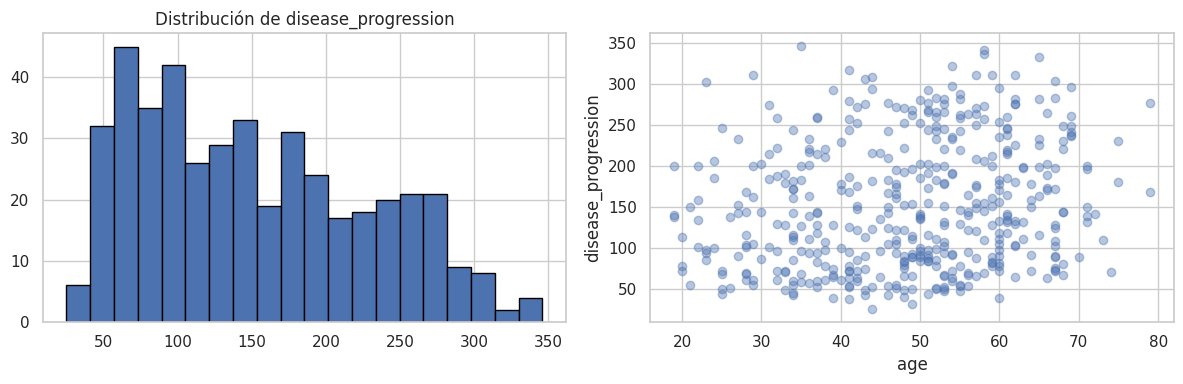

In [6]:
# --- Paso 5: análisis de features y dependencias con el target ---
feature_cols_eda = infer_feature_columns(df, TARGET_COL, DROP_COLS, FEATURE_COLS)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[TARGET_COL].hist(ax=axes[0], bins=20, edgecolor="black")
axes[0].set_title(f"Distribución de {TARGET_COL}")
num_feat = df[feature_cols_eda].select_dtypes(include=[np.number]).columns
if len(num_feat):
    corrs = df[num_feat].corrwith(df[TARGET_COL]).abs().sort_values(ascending=False)
    feat = corrs.index[0] if len(corrs.dropna()) else num_feat[0]
    axes[1].scatter(df[feat], df[TARGET_COL], alpha=0.4)
    axes[1].set_xlabel(feat)
    axes[1].set_ylabel(TARGET_COL)
plt.tight_layout()
plt.show()

# --- Correlación entre features numéricas y target ---
num_cols = [
    c for c in feature_cols_eda
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
]
cols_corr = list(dict.fromkeys(num_cols + [TARGET_COL]))

top_feat = None
if len(cols_corr) >= 2 and pd.api.types.is_numeric_dtype(df[TARGET_COL]):
    corr = df[cols_corr].corr(numeric_only=True)
    size = max(5, 0.75 * len(cols_corr))
    fig, ax = plt.subplots(figsize=(size, size))
    sns.heatmap(
        corr,
        annot=len(cols_corr) <= 12,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        ax=ax,
    )
    ax.set_title("Correlación: features numéricas y target")
    plt.tight_layout()
    plt.show()
    s = corr[TARGET_COL].drop(TARGET_COL, errors="ignore").abs()
    if len(s):
        top_feat = s.idxmax()

if top_feat is None:
    others = [c for c in feature_cols_eda if c in df.columns and c != TARGET_COL]
    top_feat = others[0] if others else None

# --- Matriz de confusión target × feature (dependencias en datos crudos) ---
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

CM_BINS = 5
CM_MAX_CLASSES = 25

if top_feat is None:
    print("No hay features para la matriz target×feature.")
else:
    y = df[TARGET_COL]
    x = df[top_feat]
    mask = y.notna() & x.notna()
    y_clean, x_clean = y[mask], x[mask]

    if pd.api.types.is_numeric_dtype(y_clean) and y_clean.nunique() > CM_MAX_CLASSES:
        y_disc, y_note = discretize_series(y_clean, CM_BINS, CM_MAX_CLASSES)
    else:
        y_disc = pd.Categorical(y_clean).codes
        y_note = "clases del target"

    if pd.api.types.is_numeric_dtype(x_clean) and x_clean.nunique() > CM_MAX_CLASSES:
        x_disc, x_note = discretize_series(x_clean, CM_BINS, CM_MAX_CLASSES)
    else:
        x_disc = pd.Categorical(x_clean).codes
        x_note = "categorías de la feature"

    cm = confusion_matrix(y_disc, x_disc)
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, colorbar=True)
    ax.set_xlabel(f"{top_feat} ({x_note})")
    ax.set_ylabel(f"{TARGET_COL} ({y_note})")
    ax.set_title(f"Dependencia en datos: {TARGET_COL} × {top_feat}")
    plt.tight_layout()
    plt.show()


## 6. Separar X / y y split train-test

In [7]:
feature_cols = infer_feature_columns(df, TARGET_COL, DROP_COLS, FEATURE_COLS)
X = df[feature_cols]
y = df[TARGET_COL]
numeric_cols, categorical_cols = infer_column_types(X, NUMERIC_COLS, CATEGORICAL_COLS)

print("Numéricas:", numeric_cols)
print("Categóricas:", categorical_cols)


X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(
    X, y, test_size=TEST_SIZE, val_size=VAL_SIZE, random_state=RANDOM_STATE
)
print(
    f"Tamaños → train: {len(X_train):,} | val: {len(X_val):,} | test: {len(X_test):,}"
)



Numéricas: ['age', 'sex', 'bmi', 'blood_pressure', 'total_cholesterol', 'ldl', 'hdl', 'thyroid', 'log_triglycerides', 'blood_sugar_level']
Categóricas: []
Tamaños → train: 264 | val: 89 | test: 89


## 7. Preprocesado (compartido por todos los modelos)

In [8]:
preprocess = build_preprocess(numeric_cols, categorical_cols)
preprocess

,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 8. Comparar modelos


,modelo,mae,rmse,r2
2,Lasso,42.4703,51.0602,0.5241
1,Ridge,42.7230,51.1031,0.5233
0,LinearRegression,42.9389,51.1937,0.5216
4,GradientBoosting,44.6183,53.8718,0.4703
7,CatBoost,44.9401,54.0364,0.4671
3,RandomForest,44.4358,54.1525,0.4648
5,HistGradientBoosting,45.3114,57.2214,0.4024
6,XGBoost,48.6243,59.8427,0.3464


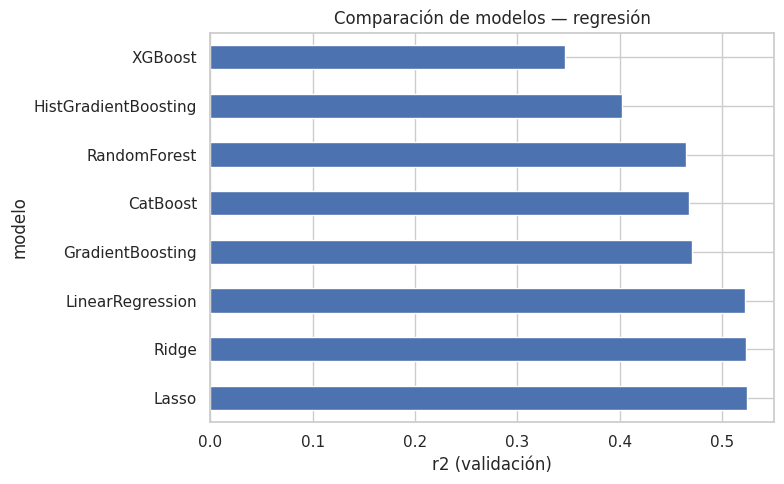

In [9]:
def regression_metrics(y_true, y_pred):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return {"mae": mae, "rmse": rmse, "r2": r2}


def evaluate_models(models, preprocess, X_train, X_val, y_train, y_val):
    rows = []
    for name, estimator in models.items():
        pipe = Pipeline([("preprocess", preprocess), ("model", estimator)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_val)
        rows.append({"modelo": name, **regression_metrics(y_val, y_pred)})
    return pd.DataFrame(rows).sort_values(METRIC_PRINCIPAL, ascending=False)

results = evaluate_models(MODELS, preprocess, X_train, X_val, y_train, y_val)
display(results.round(4))

ax = results.plot(x="modelo", y=METRIC_PRINCIPAL, kind="barh", legend=False, figsize=(8, 5))
ax.set_xlabel(f"{METRIC_PRINCIPAL} (validación)")
ax.set_title("Comparación de modelos — regresión")
plt.tight_layout()
plt.show()




## 9. Detalle del mejor modelo

Mejor modelo (val): Lasso
Métricas en test (tras reentrenar con train+val):


,mae,rmse,r2
0,44.6876,55.8799,0.4106


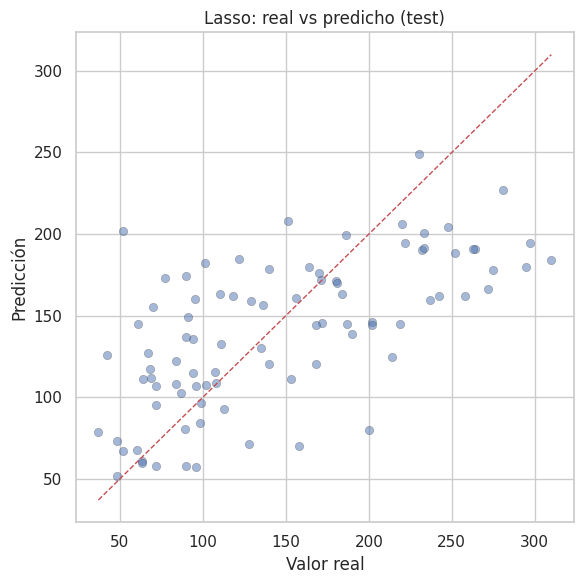

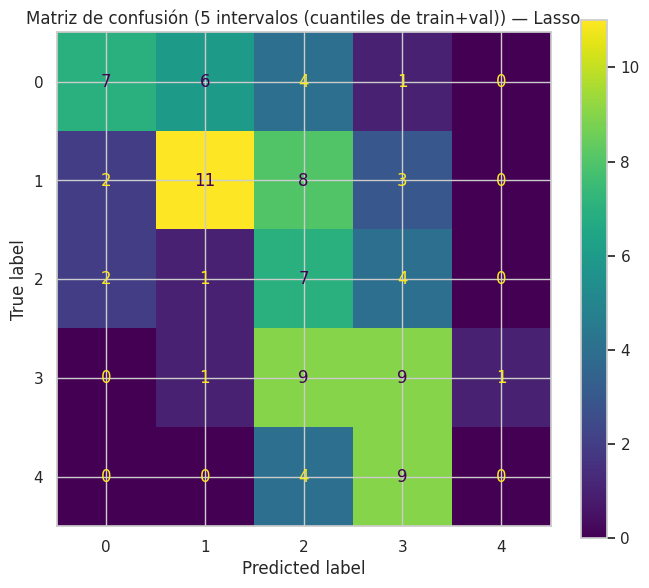

In [10]:
best_name = results.iloc[0]["modelo"]
print(f"Mejor modelo (val): {best_name}")

best_est = MODELS[best_name]
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

best_pipe = Pipeline([("preprocess", preprocess), ("model", best_est)])
best_pipe.fit(X_trainval, y_trainval)
y_pred_test = best_pipe.predict(X_test)

print("Métricas en test (tras reentrenar con train+val):")
display(pd.DataFrame([regression_metrics(y_test, y_pred_test)]).round(4))

# --- Scatter real vs predicho ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_test, alpha=0.5, edgecolors="k", linewidths=0.3)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("Valor real")
ax.set_ylabel("Predicción")
ax.set_title(f"{best_name}: real vs predicho (test)")
plt.tight_layout()
plt.show()




## Checklist: nuevo dataset

1. Coloca el CSV en `data/` y actualiza `DATA_PATH`, `TARGET_COL` y `DROP_COLS`.
2. Revisa faltantes y `dtypes` (celdas de EDA).
3. Ajusta `NUMERIC_COLS` / `CATEGORICAL_COLS` si la detección automática falla.
4. En clasificación, comprueba el balance de clases.
5. Opcional: edita `build_models()` para añadir o quitar algoritmos.
6. Ejecuta todas las celdas y compara la tabla de resultados.
